# Motorneuron J-PCMCI+ Connectivity Matrices

This notebook runs Tigramite J-PCMCI+ on motorneuron traces loaded from the `ica-denoising` dataset registry. It saves collapsed binary adjacency matrices for later graph-stability analysis and does not compute recovery or stability metrics.

Each dataset pickle is a `dict[int, np.ndarray]` keyed by the configured `TAU_MAX`. Rerun with another `TAU_MAX` value to add or replace one conditioning depth.

In [1]:
from __future__ import annotations

import json
import sys
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd

SEARCH_ROOTS = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
PROJECT_ROOT = next(
    (
        candidate
        for root in SEARCH_ROOTS
        for candidate in (root, root / "ica-denoising")
        if (candidate / "pyproject.toml").exists()
        and (candidate / "src" / "ica_denoising").exists()
    ),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate the ica-denoising project root.")

SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from ica_denoising.bss_notebook import available_datasets, load_traces

pd.set_option("display.max_colwidth", 120)
print(f"Project root: {PROJECT_ROOT}")

try:
    from tigramite import data_processing as pp
    from tigramite.independence_tests.parcorr_mult import ParCorrMult
    from tigramite.jpcmciplus import JPCMCIplus
except ImportError as exc:
    raise ImportError(
        "J-PCMCI+ requires tigramite in the active ica-denoising notebook kernel."
    ) from exc


Project root: /Users/sadiqadedayo/Documents/projects/ICA/ica-denoising


In [2]:
motorneuron_datasets = available_datasets(PROJECT_ROOT).query(
    "group == 'motorneurons' and exists"
).copy()
motorneuron_datasets[["fish_num", "trace_num"]] = motorneuron_datasets[
    "data_name"
].str.extract(r"fish(\d+)_trace(\d+)").astype(int)
motorneuron_datasets["modality_order"] = motorneuron_datasets["modality"].map(
    {"dff": 0, "f_smooth": 1}
).fillna(99)
motorneuron_datasets = motorneuron_datasets.sort_values(
    ["fish_num", "trace_num", "modality_order"]
).reset_index(drop=True)

DATASET_KEYS = motorneuron_datasets["key"].tolist()
motorneuron_datasets[
    ["key", "data_name", "recording_id", "modality", "default_n_components"]
]


,key,data_name,recording_id,modality,default_n_components
0,motorneurons/fish3_trace1_dff,fish3_trace1_dff,fish3_trace1,dff,14.0
1,motorneurons/fish3_trace1_f_smooth,fish3_trace1_f_smooth,fish3_trace1,f_smooth,14.0
2,motorneurons/fish3_trace2_dff,fish3_trace2_dff,fish3_trace2,dff,11.0
3,motorneurons/fish3_trace2_f_smooth,fish3_trace2_f_smooth,fish3_trace2,f_smooth,11.0
4,motorneurons/fish5_trace2_dff,fish5_trace2_dff,fish5_trace2,dff,17.0
5,motorneurons/fish5_trace2_f_smooth,fish5_trace2_f_smooth,fish5_trace2,f_smooth,17.0


In [3]:
METHOD_LABEL = "jpcmciplus"
TAU_MIN = 0
TAU_MAX = 2
PC_ALPHA = 0.05
REPLACE_EXISTING_P = True

DATASET_KEY = "motorneurons/fish3_trace2_dff"
CLEANED_METHODS = ("fastica", "infomax", "sobi", "jade")
REQUIRE_SAVED_CLEANED = True
DATASET_OUTPUT_NAME = DATASET_KEY.split("/", 1)[1]
PLOT_VARIANT_ORDER = ("raw", "fastica_cleaned", "infomax_cleaned", "sobi_cleaned", "jade_cleaned")
PLOT_VARIANT_TITLES = {"raw": "raw", "fastica_cleaned": "FastICA", "infomax_cleaned": "Infomax", "sobi_cleaned": "SOBI", "jade_cleaned": "JADE"}

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "connectivity" / "motorneurons" / METHOD_LABEL / DATASET_OUTPUT_NAME
ADJACENCY_PATH = OUTPUT_DIR / "connectivity_matrices.pkl"
FIGURE_OUTPUT_PATH = OUTPUT_DIR / "connectivity_grid.png"
GRAPH_DIR = OUTPUT_DIR / "graphs"
METADATA_DIR = OUTPUT_DIR / "metadata"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
GRAPH_DIR.mkdir(parents=True, exist_ok=True)
METADATA_DIR.mkdir(parents=True, exist_ok=True)

print(f"Method: {METHOD_LABEL}")
print(f"Dataset: {DATASET_KEY}")
print(f"Trace variants: raw + {', '.join(CLEANED_METHODS)}")
print(f"P/tau value saved by this run: {TAU_MAX}")
print(f"Connectivity pickle: {ADJACENCY_PATH.relative_to(PROJECT_ROOT)}")


Method: jpcmciplus
Dataset: motorneurons/fish3_trace2_dff
Trace variants: raw + fastica, infomax, sobi, jade
P/tau value saved by this run: 2
Connectivity pickle: outputs/connectivity/motorneurons/jpcmciplus/fish3_trace2_dff/connectivity_matrices.pkl


In [4]:
from csl.utils import (
    graph_to_adjacency,
    load_bss_trace_variants,
    load_motorneuron_mid,
    plot_motoneuron_connectivity_grid,
    save_variant_adjacency_dict,
    write_json,
    write_variant_adjacency_dict,
)

TRACE_VARIANTS = load_bss_trace_variants(
    DATASET_KEY,
    PROJECT_ROOT,
    methods=CLEANED_METHODS,
    require_saved_cleaned=REQUIRE_SAVED_CLEANED,
)
MOTORNEURON_MID = load_motorneuron_mid(DATASET_KEY, PROJECT_ROOT)
variant_overview = pd.DataFrame(
    {
        "variant_name": variant["variant_name"],
        "variant_label": variant["variant_label"],
        "source_method": variant["source_method"],
        "source_path": variant["source_path"],
        "trace_shape_neurons_by_frames": [tuple(variant["traces"].shape)],
    }
    for variant in TRACE_VARIANTS
)
variant_overview


,variant_name,variant_label,source_method,source_path,trace_shape_neurons_by_frames
0,raw,fish3_trace2_dff: raw,NaN,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/data/motorneurons/df_motoneurons_F3T1_F3T2_F5T2.pkl,"[(11, 1000)]"
1,fastica_cleaned,fish3_trace2_dff: fastica,fastica,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/outputs/linear/motorneurons/fish3_trace2_dff/fastica/cleane...,"[(11, 1000)]"
2,infomax_cleaned,fish3_trace2_dff: infomax,infomax,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/outputs/linear/motorneurons/fish3_trace2_dff/infomax/cleane...,"[(11, 1000)]"
3,sobi_cleaned,fish3_trace2_dff: sobi,sobi,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/outputs/linear/motorneurons/fish3_trace2_dff/sobi/cleaned/c...,"[(11, 1000)]"
4,jade_cleaned,fish3_trace2_dff: jade,jade,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/outputs/linear/motorneurons/fish3_trace2_dff/jade/cleaned/c...,"[(11, 1000)]"


In [5]:
records: list[dict[str, object]] = []
saved_adjacencies: dict[str, np.ndarray] | None = None

for variant in TRACE_VARIANTS:
    spec = variant["dataset"]
    variant_name = str(variant["variant_name"])
    X = np.asarray(variant["traces"], dtype=float)

    dataframe = pp.DataFrame(X.T)
    node_classification = {i: "system" for i in range(X.shape[0])}
    jpcmciplus = JPCMCIplus(
        dataframe=dataframe,
        cond_ind_test=ParCorrMult(significance="analytic"),
        node_classification=node_classification,
        verbosity=0,
    )
    results_pcmci = jpcmciplus.run_jpcmciplus(
        tau_min=TAU_MIN,
        tau_max=TAU_MAX,
        pc_alpha=PC_ALPHA,
    )
    causal_graph = results_pcmci["graph"]
    adjacency = graph_to_adjacency(causal_graph)

    graph_path = GRAPH_DIR / f"{variant_name}.pkl"
    metadata_path = METADATA_DIR / f"{variant_name}.json"

    saved_adjacencies = save_variant_adjacency_dict(
        ADJACENCY_PATH,
        variant_name,
        adjacency,
        replace_existing_variant=REPLACE_EXISTING_P,
    )
    write_variant_adjacency_dict(ADJACENCY_PATH, saved_adjacencies)
    pd.to_pickle(causal_graph, graph_path)

    run_metadata = {
        "saved_at": datetime.now(timezone.utc).isoformat(),
        "artifact_kind": "connectivity_matrix",
        "method_label": METHOD_LABEL,
        "dataset_key": spec.key,
        "data_name": spec.data_name,
        "trace_variant": variant_name,
        "variant_label": variant["variant_label"],
        "source_method": variant["source_method"],
        "source_path": variant["source_path"],
        "trace_shape_neurons_by_frames": list(X.shape),
        "tau_min": int(TAU_MIN),
        "tau_max": int(TAU_MAX),
        "pc_alpha": float(PC_ALPHA),
        "adjacency_pickle": str(ADJACENCY_PATH.relative_to(PROJECT_ROOT)),
        "adjacency_keys": sorted(saved_adjacencies),
        "tigramite_graph": str(graph_path.relative_to(PROJECT_ROOT)),
    }
    write_json(metadata_path, run_metadata)
    records.append(run_metadata)
    print(f"Saved {variant_name}: shape={adjacency.shape}")

run_summary = pd.DataFrame(records)
run_summary.to_csv(OUTPUT_DIR / f"run_summary_tau{TAU_MAX}.csv", index=False)
write_json(
    OUTPUT_DIR / f"run_summary_tau{TAU_MAX}.json",
    {
        "adjacency_pickle": str(ADJACENCY_PATH.relative_to(PROJECT_ROOT)),
        "adjacency_keys": sorted(saved_adjacencies) if saved_adjacencies is not None else [],
        "records": records,
    },
)
run_summary


Saved raw: shape=(11, 11)
Saved fastica_cleaned: shape=(11, 11)
Saved infomax_cleaned: shape=(11, 11)
Saved sobi_cleaned: shape=(11, 11)
Saved jade_cleaned: shape=(11, 11)


,saved_at,artifact_kind,method_label,dataset_key,data_name,trace_variant,variant_label,source_method,source_path,trace_shape_neurons_by_frames,tau_min,tau_max,pc_alpha,adjacency_pickle,adjacency_keys,tigramite_graph
0,2026-06-14T14:29:35.872770+00:00,connectivity_matrix,jpcmciplus,motorneurons/fish3_trace2_dff,fish3_trace2_dff,raw,fish3_trace2_dff: raw,NaN,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/data/motorneurons/df_motoneurons_F3T1_F3T2_F5T2.pkl,"[11, 1000]",0,2,0.05,outputs/connectivity/motorneurons/jpcmciplus/fish3_trace2_dff/connectivity_matrices.pkl,"[fastica_cleaned, infomax_cleaned, jade_cleaned, raw, sobi_cleaned]",outputs/connectivity/motorneurons/jpcmciplus/fish3_trace2_dff/graphs/raw.pkl
1,2026-06-14T14:29:39.805642+00:00,connectivity_matrix,jpcmciplus,motorneurons/fish3_trace2_dff,fish3_trace2_dff,fastica_cleaned,fish3_trace2_dff: fastica,fastica,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/outputs/linear/motorneurons/fish3_trace2_dff/fastica/cleane...,"[11, 1000]",0,2,0.05,outputs/connectivity/motorneurons/jpcmciplus/fish3_trace2_dff/connectivity_matrices.pkl,"[fastica_cleaned, infomax_cleaned, jade_cleaned, raw, sobi_cleaned]",outputs/connectivity/motorneurons/jpcmciplus/fish3_trace2_dff/graphs/fastica_cleaned.pkl
2,2026-06-14T14:29:43.684676+00:00,connectivity_matrix,jpcmciplus,motorneurons/fish3_trace2_dff,fish3_trace2_dff,infomax_cleaned,fish3_trace2_dff: infomax,infomax,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/outputs/linear/motorneurons/fish3_trace2_dff/infomax/cleane...,"[11, 1000]",0,2,0.05,outputs/connectivity/motorneurons/jpcmciplus/fish3_trace2_dff/connectivity_matrices.pkl,"[fastica_cleaned, infomax_cleaned, jade_cleaned, raw, sobi_cleaned]",outputs/connectivity/motorneurons/jpcmciplus/fish3_trace2_dff/graphs/infomax_cleaned.pkl
3,2026-06-14T14:29:49.747323+00:00,connectivity_matrix,jpcmciplus,motorneurons/fish3_trace2_dff,fish3_trace2_dff,sobi_cleaned,fish3_trace2_dff: sobi,sobi,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/outputs/linear/motorneurons/fish3_trace2_dff/sobi/cleaned/c...,"[11, 1000]",0,2,0.05,outputs/connectivity/motorneurons/jpcmciplus/fish3_trace2_dff/connectivity_matrices.pkl,"[fastica_cleaned, infomax_cleaned, jade_cleaned, raw, sobi_cleaned]",outputs/connectivity/motorneurons/jpcmciplus/fish3_trace2_dff/graphs/sobi_cleaned.pkl
4,2026-06-14T14:29:53.047065+00:00,connectivity_matrix,jpcmciplus,motorneurons/fish3_trace2_dff,fish3_trace2_dff,jade_cleaned,fish3_trace2_dff: jade,jade,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/outputs/linear/motorneurons/fish3_trace2_dff/jade/cleaned/c...,"[11, 1000]",0,2,0.05,outputs/connectivity/motorneurons/jpcmciplus/fish3_trace2_dff/connectivity_matrices.pkl,"[fastica_cleaned, infomax_cleaned, jade_cleaned, raw, sobi_cleaned]",outputs/connectivity/motorneurons/jpcmciplus/fish3_trace2_dff/graphs/jade_cleaned.pkl


Saved figure to outputs/connectivity/motorneurons/jpcmciplus/fish3_trace2_dff/connectivity_grid.png


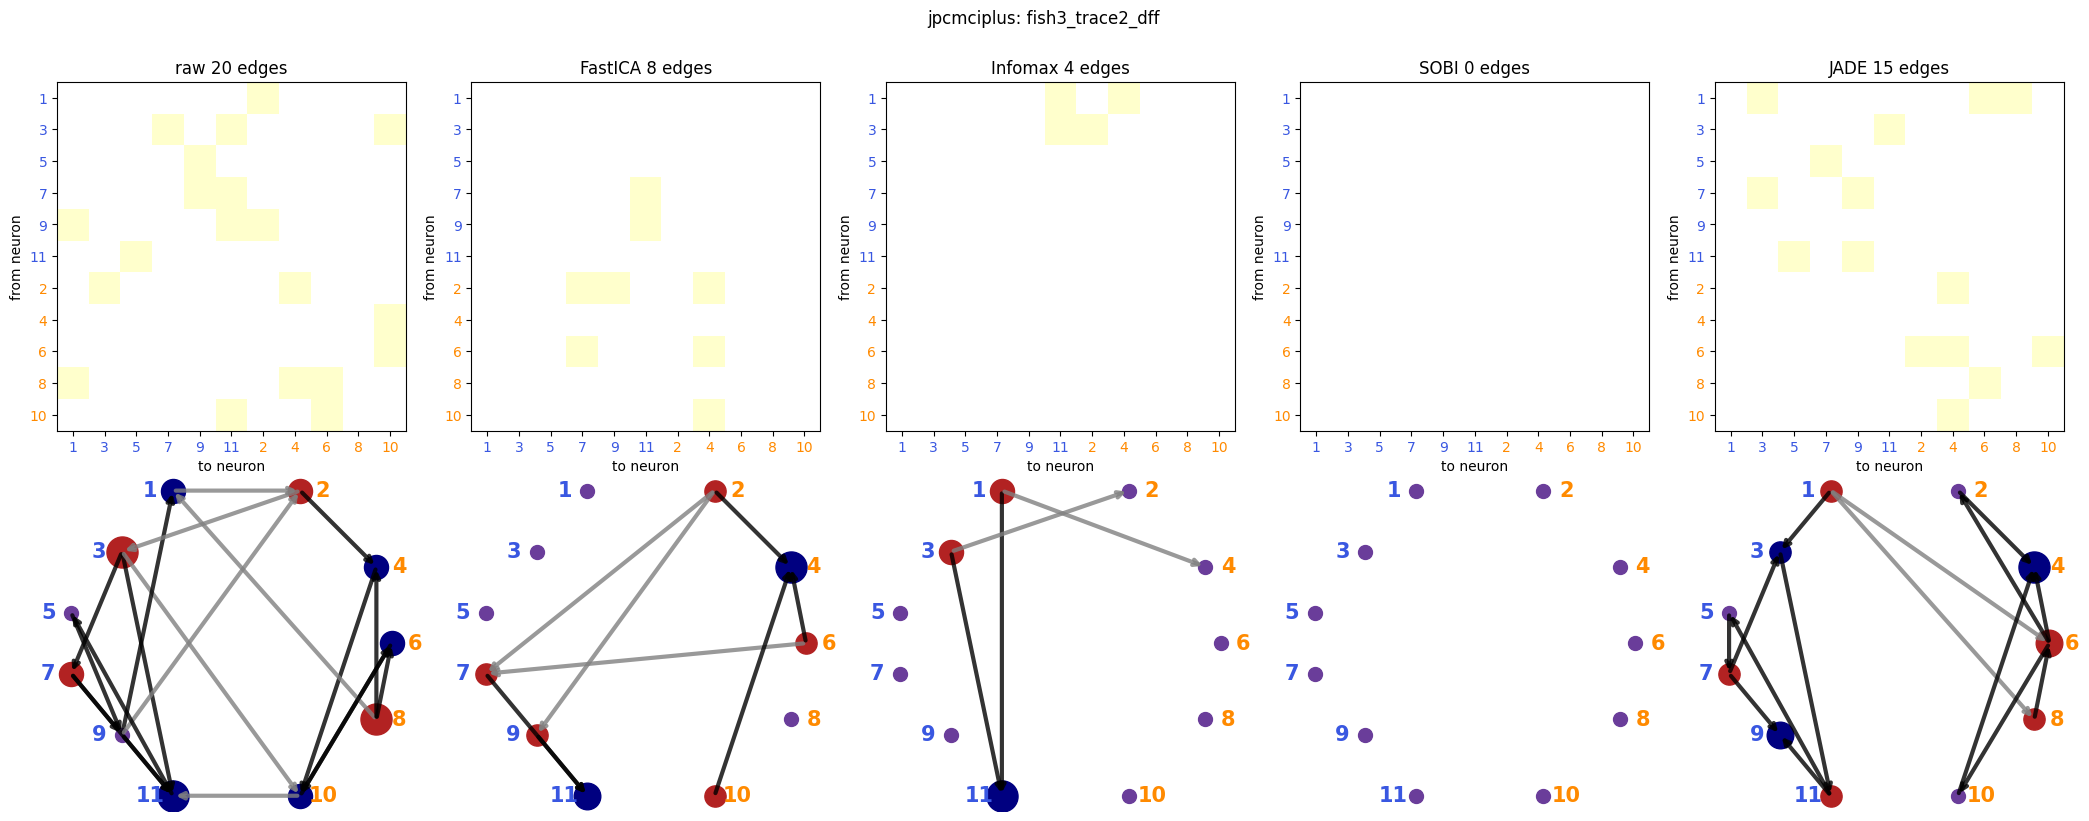

In [6]:
saved_connectivity = pd.read_pickle(ADJACENCY_PATH)
fig, axes = plot_motoneuron_connectivity_grid(
    saved_connectivity,
    mid=MOTORNEURON_MID,
    variant_order=PLOT_VARIANT_ORDER,
    variant_titles=PLOT_VARIANT_TITLES,
    figure_title=f"{METHOD_LABEL}: {DATASET_OUTPUT_NAME}",
)
fig.savefig(FIGURE_OUTPUT_PATH, dpi=300, bbox_inches="tight")
print(f"Saved figure to {FIGURE_OUTPUT_PATH.relative_to(PROJECT_ROOT)}")
